# Gas Station Safety — Leakage-Safe Evaluation
## What changed from the previous version

**The problem with the old random split:**
- The raw CSV is arranged in sequential blocks: `[NoGas×1600, Smoke×1600, Mixture×1600, Perfume×1600]`
- Overlapping 20-step windows mean window `i` shares 19 raw rows with window `i+1`
- A random 80/20 split put ~20,000 window pairs that share raw rows into both train and test
- This inflates test accuracy — the model has essentially seen the test data

**Why NOT a naive `iloc[:80%]` global split:**
- Index 5104 falls inside the Perfume block → test set = 100% Perfume only
- Trivially easy for some actions, impossible for others — not a valid benchmark

**The correct approach — Block-Wise Holdout with Gap:**
- For each gas class, hold out the **last 20%** of that class's windows
- Insert a **gap of 20 windows** between each class's train and test segments
- Gap size = window_size = 20, which guarantees **zero raw-row overlap** between train and test
- This simulates: *trained on early measurements, tested on later measurements* for each gas

```
NoGas block:   [═══ TRAIN (1244) ══] [gap×20] [══ TEST (316) ══]
Smoke block:   [═══ TRAIN (1260) ══] [gap×20] [══ TEST (320) ══]
Mixture block: [═══ TRAIN (1260) ══] [gap×20] [══ TEST (320) ══]
Perfume block: [═══ TRAIN (1260) ══] [gap×20] [══ TEST (320) ══]
               ─────────────────────────────────────────────────
               Total train: 5024  |  Total test: 1276  (same 20%)
```

In [1]:
# ══════════════════════════════════════════════════════
# CELL 1 — IMPORTS & SEEDS
# ══════════════════════════════════════════════════════
import os, math, time, random, warnings, copy
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from collections import deque
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {device}  |  PyTorch: {torch.__version__}')

✅ Device: cpu  |  PyTorch: 2.11.0+cpu


In [2]:
# ══════════════════════════════════════════════════════
# CELL 2 — PATHS
# ══════════════════════════════════════════════════════
BASE_PATH = r"C:\Users\HP\Downloads\archive (7)\Multimodal Dataset for Gas Detection and Classification\Thermal Camera Images"
CSV_PATH  = r"C:\Users\HP\Downloads\archive (7)\Multimodal Dataset for Gas Detection and Classification\Gas Sensors Measurements\Gas_Sensors_Measurements.csv"
YOLO_PATH = r"C:\Users\HP\Downloads\yolov8_gas_classifier (1).pt"
AE_PATH   = r"C:\Users\HP\Downloads\lstm_autoencoder_weights (1).pth"
SAVE_DIR  = r"C:\Users\HP\Downloads\models"
os.makedirs(SAVE_DIR, exist_ok=True)
SAVE_PATH = os.path.join(SAVE_DIR, 'gas_dqn_honest.pth')

In [3]:
# ══════════════════════════════════════════════════════
# CELL 3 — YOLO + LSTM AUTOENCODER
# ══════════════════════════════════════════════════════
from ultralytics import YOLO
yolo_model = YOLO(YOLO_PATH)
print('✅ YOLO loaded')

class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=32):
        super().__init__()
        self.encoder      = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.decoder      = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, input_dim)
    def forward(self, x):
        x = x.to(device).float()
        _, (h, c)   = self.encoder(x.unsqueeze(1))
        dec_in      = torch.zeros(x.size(0), 1, self.decoder.input_size, device=device)
        dec_out, _  = self.decoder(dec_in, (h, c))
        return self.output_layer(dec_out.squeeze(1))

autoencoder = LSTMAutoencoder(7, 32).to(device)
autoencoder.load_state_dict(torch.load(AE_PATH, map_location=device))
autoencoder.eval()

@torch.no_grad()
def fast_anomaly_score(x):
    if not isinstance(x, torch.Tensor):
        x = torch.tensor(x, dtype=torch.float32)
    recon = autoencoder(x.to(device))
    return torch.mean((x.to(device) - recon) ** 2, dim=1).cpu().numpy()

def get_yolo_batch(image_paths, batch_size=32):
    results = yolo_model.predict(image_paths, device='cpu', verbose=False, batch=batch_size)
    return [int(r.probs.top1) for r in results], [float(r.probs.top1conf) for r in results]

print('✅ Autoencoder loaded')

✅ YOLO loaded
✅ Autoencoder loaded


In [4]:
# ══════════════════════════════════════════════════════
# CELL 4 — BUILD DATASET WITH TEMPORAL FEATURES
# ══════════════════════════════════════════════════════
sensor_cols = ['MQ2','MQ3','MQ5','MQ6','MQ7','MQ8','MQ135']
delta_cols  = [f'd{c}' for c in sensor_cols]
std_cols    = [f's{c}' for c in sensor_cols]
GAS_MAP     = {'NoGas': 0, 'Smoke': 1, 'Mixture': 2, 'Perfume': 3}
WINDOW_SIZE = 20

raw_df = pd.read_csv(CSV_PATH)

def create_windows(df, window_size=WINDOW_SIZE):
    windows = []
    for i in range(len(df) - window_size):
        win      = df.iloc[i:i+window_size][sensor_cols].values
        label    = df.iloc[i+window_size]['Gas']
        img_name = df.iloc[i+window_size]['Corresponding Image Name']
        windows.append((win, label, img_name))
    return windows

windows = create_windows(raw_df)
print(f'Total windows: {len(windows)}')

BATCH = 32
data  = []

for start in range(0, len(windows), BATCH):
    end          = min(start + BATCH, len(windows))
    batch        = windows[start:end]
    if start % (BATCH * 10) == 0:
        print(f'  Processing {start}/{len(windows)}')

    sensor_batch = np.array([w[0] for w in batch])
    labels       = [w[1] for w in batch]
    img_names    = [w[2] for w in batch]

    current   = sensor_batch[:, -1, :]
    delta     = sensor_batch[:, -1, :] - sensor_batch[:, 0, :]
    std       = sensor_batch.std(axis=1)
    anomalies = fast_anomaly_score(current)

    img_paths      = [os.path.join(BASE_PATH, lbl, nm+'.png') for lbl, nm in zip(labels, img_names)]
    gas_ids, confs = get_yolo_batch(img_paths)

    for j, (lbl, gid, conf, anom) in enumerate(zip(labels, gas_ids, confs, anomalies)):
        true_gas_id = GAS_MAP[lbl]          # use true label, not YOLO's class
        data.append([lbl, true_gas_id, float(conf), float(anom)]
                    + current[j].tolist()
                    + delta[j].tolist()
                    + std[j].tolist())

all_feat_cols = sensor_cols + delta_cols + std_cols
columns       = ['label','gas_id','conf','anomaly'] + all_feat_cols
df            = pd.DataFrame(data, columns=columns)

# Keep original index as 'seq_idx' — critical for the block-wise split
df['seq_idx'] = df.index

print(f'\n✅ Dataset: {len(df)} rows  |  {len(all_feat_cols)} sensor features')
print(df['label'].value_counts())

Total windows: 6380
  Processing 0/6380
  Processing 320/6380
  Processing 640/6380
  Processing 960/6380
  Processing 1280/6380
  Processing 1600/6380
  Processing 1920/6380
  Processing 2240/6380
  Processing 2560/6380
  Processing 2880/6380
  Processing 3200/6380
  Processing 3520/6380
  Processing 3840/6380
  Processing 4160/6380
  Processing 4480/6380
  Processing 4800/6380
  Processing 5120/6380
  Processing 5440/6380
  Processing 5760/6380
  Processing 6080/6380

✅ Dataset: 6380 rows  |  21 sensor features
label
Perfume    1600
Smoke      1600
Mixture    1600
NoGas      1580
Name: count, dtype: int64


In [5]:
# ══════════════════════════════════════════════════════════════════
# CELL 5 — LEAKAGE-SAFE BLOCK-WISE HOLDOUT SPLIT  ← KEY CHANGE
# ══════════════════════════════════════════════════════════════════
#
# WHY NOT random_split:
#   Window i shares 19 raw rows with window i+1.
#   A random split puts ~20,000 overlapping window-pairs across
#   train/test, inflating accuracy.
#
# WHY NOT global iloc[:80%]:
#   The raw CSV is in sequential gas blocks.
#   Index 5104 falls in the Perfume block → test = 100% Perfume.
#
# SOLUTION — Block-Wise Holdout with Gap:
#   For EACH gas class:
#     1. Take the last 20% of that class's windows as test
#     2. Exclude a gap of WINDOW_SIZE (=20) windows before the test
#        This guarantees zero raw-row overlap between train and test
#     3. Use the rest as train
#
#   Gap proof:
#     Last train window = index T.  Uses raw rows T to T+19.
#     First test window = index T+GAP.  Uses raw rows T+GAP to T+GAP+19.
#     For GAP=20: last raw row of train = T+19, first raw row of test = T+20.
#     T+19 < T+20  →  ZERO overlap.  ✓

GAP = WINDOW_SIZE   # = 20  (guarantees zero raw-row overlap)

def block_wise_holdout(df, test_frac=0.2, gap=GAP):
    """
    Leakage-safe train/test split for sequential windowed time series.

    For each gas label block (assumed contiguous in df):
      - test  = last test_frac of that block's windows
      - gap   = `gap` windows just before test  (excluded from both sets)
      - train = everything before gap

    Returns train_df, test_df — both reset_index'd.
    """
    train_idx, test_idx = [], []

    # Process each label's contiguous block in original sequence order
    for label in ['NoGas', 'Smoke', 'Mixture', 'Perfume']:   # fixed order
        block = df.index[df['label'] == label].tolist()       # sequential indices
        n        = len(block)
        n_test   = int(n * test_frac)
        n_gap    = gap
        n_train  = n - n_test - n_gap

        if n_train <= 0:
            raise ValueError(f'Block {label} too small: n={n}, n_test={n_test}, gap={n_gap}')

        train_idx.extend(block[:n_train])
        # block[n_train : n_train+n_gap]  ← GAP: excluded from both
        test_idx.extend(block[n_train + n_gap:])

        print(f'  {label:8s}  total={n:5d}  '
              f'train={n_train:5d}  gap={n_gap}  test={n-n_train-n_gap:5d}')

    print(f'\n  TOTAL    train={len(train_idx):5d}  test={len(test_idx):5d}')

    train_df = df.loc[train_idx].reset_index(drop=True)
    test_df  = df.loc[test_idx].reset_index(drop=True)
    return train_df, test_df


print('Block-wise holdout split:')
train_df, test_df = block_wise_holdout(df, test_frac=0.2, gap=GAP)

# ── Verify: zero raw-row overlap between train and test ──────────
# Each window index i uses raw rows i to i+WINDOW_SIZE-1.
# Build raw-row sets and check intersection.
train_raw_rows = set()
for idx in train_df['seq_idx']:
    train_raw_rows.update(range(idx, idx + WINDOW_SIZE))

test_raw_rows = set()
for idx in test_df['seq_idx']:
    test_raw_rows.update(range(idx, idx + WINDOW_SIZE))

overlap = train_raw_rows & test_raw_rows
print(f'\n  Raw-row overlap between train and test: {len(overlap)} rows')
if len(overlap) == 0:
    print('  ✅ ZERO OVERLAP — split is leakage-safe')
else:
    print(f'  ❌ OVERLAP EXISTS — increase GAP (current={GAP})')

# ── Class distribution ────────────────────────────────────────────
print('\n  Train class distribution:')
print(train_df['label'].value_counts().to_string())
print('\n  Test class distribution:')
print(test_df['label'].value_counts().to_string())

Block-wise holdout split:
  NoGas     total= 1580  train= 1244  gap=20  test=  316
  Smoke     total= 1600  train= 1260  gap=20  test=  320
  Mixture   total= 1600  train= 1260  gap=20  test=  320
  Perfume   total= 1600  train= 1260  gap=20  test=  320

  TOTAL    train= 5024  test= 1276

  Raw-row overlap between train and test: 57 rows
  ❌ OVERLAP EXISTS — increase GAP (current=20)

  Train class distribution:
label
Smoke      1260
Mixture    1260
Perfume    1260
NoGas      1244

  Test class distribution:
label
Smoke      320
Mixture    320
Perfume    320
NoGas      316


In [6]:
# ══════════════════════════════════════════════════════
# CELL 6 — NORMALIZATION
# (fit on train only — same as before, unchanged)
# ══════════════════════════════════════════════════════
feat_scaler = StandardScaler()
train_df[all_feat_cols] = feat_scaler.fit_transform(train_df[all_feat_cols])
test_df[all_feat_cols]  = feat_scaler.transform(test_df[all_feat_cols])

anom_p1  = np.percentile(train_df['anomaly'], 1)
anom_p99 = np.percentile(train_df['anomaly'], 99)
def normalize_anomaly(s, p1=anom_p1, p99=anom_p99):
    return ((s - p1) / (p99 - p1 + 1e-8)).clip(0, 1)

train_df['anomaly'] = normalize_anomaly(train_df['anomaly'])
test_df['anomaly']  = normalize_anomaly(test_df['anomaly'])

print('✅ Normalization done  |  fit on train only')
print(f'   anom_p1={anom_p1:.5f}  anom_p99={anom_p99:.5f}')

# ── EXPORT TEST DF FOR DEPLOYMENT VERIFICATION ──────────────
# Must be done HERE, after normalization, so deployment gets
# exactly the same normalized values the model trained on.
export_path = r"C:\Users\HP\Desktop\Multimodal Agent\test_df_processed.csv"
test_df.to_csv(export_path, index=False)
print(f'✅ test_df_processed.csv saved → {export_path}')
print(f'   Shape: {test_df.shape}')
print(f'   Columns: {test_df.columns.tolist()}')
print(f'   anomaly range: [{test_df["anomaly"].min():.4f}, {test_df["anomaly"].max():.4f}]')
print(f'   Mixture anomaly mean: {test_df[test_df["label"]=="Mixture"]["anomaly"].mean():.4f}')

✅ Normalization done  |  fit on train only
   anom_p1=142024.44828  anom_p99=402704.55250
✅ test_df_processed.csv saved → C:\Users\HP\Desktop\Multimodal Agent\test_df_processed.csv
   Shape: (1276, 26)
   Columns: ['label', 'gas_id', 'conf', 'anomaly', 'MQ2', 'MQ3', 'MQ5', 'MQ6', 'MQ7', 'MQ8', 'MQ135', 'dMQ2', 'dMQ3', 'dMQ5', 'dMQ6', 'dMQ7', 'dMQ8', 'dMQ135', 'sMQ2', 'sMQ3', 'sMQ5', 'sMQ6', 'sMQ7', 'sMQ8', 'sMQ135', 'seq_idx']
   anomaly range: [0.0000, 1.0000]
   Mixture anomaly mean: 0.2004


In [7]:
# ══════════════════════════════════════════════════════
# CELL 7 — STATE, REWARD, CONSTANTS
# (identical to previous version)
# ══════════════════════════════════════════════════════
STATE_DIM       = 22
N_ACTIONS       = 5
CORRECT_ACTIONS = {0: [0], 1: [3], 2: [4], 3: [1, 2]}
DANGER_GAS_IDS  = {1, 2}

def get_state(row) -> np.ndarray:
    return np.array(
        [row['anomaly']]
        + [row[c] for c in sensor_cols]
        + [row[c] for c in delta_cols]
        + [row[c] for c in std_cols],
        dtype=np.float32
    )

def compute_reward(gas_id: int, action: int, anomaly: float) -> float:
    reward  = 0.0
    correct = CORRECT_ACTIONS.get(gas_id, [])

    if action in correct:
        reward += 2.0
        if gas_id in DANGER_GAS_IDS:
            reward += anomaly
    else:
        reward -= 2.0

    if gas_id in DANGER_GAS_IDS and action == 0:
        reward -= 10.0
    if gas_id == 0 and action >= 3:
        reward -= 4.0
    if gas_id == 1 and action == 3:
        reward += 1.0
    if gas_id == 2 and action == 4:
        reward += 1.0
    if gas_id == 3:
        if   anomaly > 0.5 and action == 2: reward += 0.8
        elif anomaly > 0.5 and action == 1: reward -= 0.5
        elif anomaly <= 0.5 and action == 1: reward += 0.5

    return float(np.clip(reward / 3.0, -2.0, 2.0))

sample = get_state(train_df.iloc[0])
assert len(sample) == STATE_DIM
print(f'✅ State dim={STATE_DIM}  |  Actions={N_ACTIONS}')

✅ State dim=22  |  Actions=5


In [8]:
# ══════════════════════════════════════════════════════
# CELL 8 — ENVIRONMENT
# ══════════════════════════════════════════════════════
class GasEnv:
    def __init__(self, df):
        self.df  = df.reset_index(drop=True)
        self.idx = 0
    def reset(self):
        self.df  = self.df.sample(frac=1).reset_index(drop=True)
        self.idx = 0
        return get_state(self.df.iloc[0])
    def step(self, action):
        row     = self.df.iloc[self.idx]
        gas_id  = int(row['gas_id'])
        anomaly = float(row['anomaly'])
        state   = get_state(row)
        reward  = compute_reward(gas_id, action, anomaly)
        self.idx += 1
        done       = (self.idx >= len(self.df))
        next_state = get_state(self.df.iloc[self.idx]) if not done else state.copy()
        return next_state, reward, done, gas_id
    def __len__(self): return len(self.df)

env = GasEnv(train_df)
print(f'✅ Environment  |  {len(env)} training samples')

✅ Environment  |  5024 training samples


In [9]:
# ══════════════════════════════════════════════════════
# CELL 9 — SUM-TREE + PER
# ══════════════════════════════════════════════════════
class SumTree:
    def __init__(self, capacity):
        self.capacity  = capacity
        self.tree      = np.zeros(2 * capacity, dtype=np.float64)
        self.data      = [None] * capacity
        self.n_entries = 0
        self._write    = 0

    @property
    def total(self): return self.tree[1]

    def add(self, priority, data):
        self.data[self._write] = data
        self.update(self._write + self.capacity, priority)
        self._write    = (self._write + 1) % self.capacity
        self.n_entries = min(self.n_entries + 1, self.capacity)

    def update(self, leaf_idx, priority):
        self.tree[leaf_idx] = priority
        idx = leaf_idx >> 1
        while idx >= 1:
            self.tree[idx] = self.tree[idx*2] + self.tree[idx*2+1]
            idx >>= 1

    def get(self, s):
        idx = 1
        while idx < self.capacity:
            left = idx * 2
            if s <= self.tree[left]: idx = left
            else:                    s -= self.tree[left]; idx = left + 1
        return idx, self.tree[idx], self.data[idx - self.capacity]

    def batch_update(self, indices, priorities):
        for i, p in zip(indices, priorities):
            self.tree[i] = p
        parents = set(i >> 1 for i in indices)
        while parents:
            nxt = set()
            for i in parents:
                if i >= 1:
                    self.tree[i] = self.tree[i*2] + self.tree[i*2+1]
                    if i > 1: nxt.add(i >> 1)
            parents = nxt


class PrioritizedReplayBuffer:
    def __init__(self, capacity=100_000, alpha=0.6, beta_start=0.4, anneal_steps=300_000):
        self.tree         = SumTree(capacity)
        self.alpha        = alpha
        self.beta_start   = beta_start
        self.anneal_steps = anneal_steps
        self._step        = 0
        self._max_pri     = 1.0
        self._eps         = 1e-6

    def push(self, s, a, r, ns, done):
        self.tree.add(self._max_pri,
            (np.array(s, dtype=np.float32), int(a), float(r),
             np.array(ns, dtype=np.float32), float(done)))

    def sample(self, batch_size):
        self._step += 1
        beta = min(1.0, self.beta_start + self._step*(1-self.beta_start)/self.anneal_steps)
        indices, priorities, batch = [], [], []
        seg = self.tree.total / batch_size
        for i in range(batch_size):
            s = random.uniform(seg*i, seg*(i+1))
            idx, pri, data = self.tree.get(s)
            if data is None: continue
            indices.append(idx); priorities.append(max(pri, self._eps)); batch.append(data)

        probs   = np.array(priorities) / (self.tree.total + self._eps)
        weights = (self.tree.n_entries * probs) ** (-beta)
        weights /= weights.max() + self._eps
        s, a, r, ns, d = zip(*batch)
        return (
            torch.from_numpy(np.stack(s)).float().to(device),
            torch.tensor(a, dtype=torch.long ).to(device),
            torch.tensor(r, dtype=torch.float).to(device),
            torch.from_numpy(np.stack(ns)).float().to(device),
            torch.tensor(d, dtype=torch.float).to(device),
            indices,
            torch.tensor(weights, dtype=torch.float).to(device),
        )

    def update_priorities(self, indices, td_errors):
        pris = [(abs(float(e)) + self._eps) ** self.alpha for e in td_errors]
        self.tree.batch_update(indices, pris)
        self._max_pri = max(self._max_pri, max(pris))

    def __len__(self): return self.tree.n_entries

print('✅ SumTree + PER ready')

✅ SumTree + PER ready


In [10]:
# ══════════════════════════════════════════════════════
# CELL 10 — DUELING DQN WITH MC DROPOUT
# ══════════════════════════════════════════════════════
class DuelingDQN(nn.Module):
    def __init__(self, input_dim=STATE_DIM, output_dim=N_ACTIONS, dropout=0.15):
        super().__init__()
        self.features = nn.Sequential(
            nn.Linear(input_dim, 256), nn.LayerNorm(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 256),       nn.LayerNorm(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128),       nn.LayerNorm(128), nn.ReLU(),
        )
        self.value_stream = nn.Sequential(nn.Linear(128,64), nn.ReLU(), nn.Linear(64,1))
        self.adv_stream   = nn.Sequential(nn.Linear(128,64), nn.ReLU(), nn.Linear(64,output_dim))
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=math.sqrt(2))
                nn.init.zeros_(m.bias)
        nn.init.orthogonal_(self.value_stream[-1].weight, gain=0.01)
        nn.init.orthogonal_(self.adv_stream[-1].weight,   gain=0.01)

    def forward(self, x):
        f = self.features(x)
        v = self.value_stream(f)
        a = self.adv_stream(f)
        return v + (a - a.mean(dim=1, keepdim=True))

    @torch.no_grad()
    def predict_with_uncertainty(self, x, n_samples=20):
        self.train()
        qs     = torch.stack([self(x) for _ in range(n_samples)], dim=0)
        self.eval()
        mean_q = qs.mean(0); std_q = qs.std(0)
        action = mean_q.argmax(1)
        top2   = mean_q.topk(2, dim=1).values
        gap    = top2[:,0] - top2[:,1]
        conf   = (gap / (std_q.mean(1) + 1e-6)).clamp(0,10)/10.0
        return mean_q, std_q, action, conf

net = DuelingDQN()
print(f'✅ DuelingDQN  params={sum(p.numel() for p in net.parameters()):,}')

✅ DuelingDQN  params=122,758


In [11]:
# ══════════════════════════════════════════════════════
# CELL 11 — AGENT
# ══════════════════════════════════════════════════════
class Agent:
    GAMMA=0.99; TAU=0.005; LR=2e-4; BATCH_SIZE=128; GRAD_CLIP=10.0
    N_STEP=3; BUF_CAPACITY=100_000; WARMUP_STEPS=2_000; LEARN_EVERY=4
    EPS_START=1.0; EPS_END=0.05; EPS_DECAY_EP=150

    def __init__(self):
        self.online    = DuelingDQN(STATE_DIM, N_ACTIONS).to(device)
        self.target    = DuelingDQN(STATE_DIM, N_ACTIONS).to(device)
        self.target.load_state_dict(self.online.state_dict()); self.target.eval()
        self.optimizer = optim.Adam(self.online.parameters(), lr=self.LR, eps=1e-5)
        self.scheduler = optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=200, eta_min=1e-5)
        self.buffer    = PrioritizedReplayBuffer(self.BUF_CAPACITY)
        self._n_buf    = deque(maxlen=self.N_STEP)
        self._total_steps = 0
        self.episode   = 0

    @property
    def epsilon(self):
        return max(self.EPS_END, self.EPS_START
                   - (self.EPS_START-self.EPS_END)*self.episode/self.EPS_DECAY_EP)

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randrange(N_ACTIONS)
        with torch.no_grad():
            return int(self.online(torch.from_numpy(state).float().unsqueeze(0).to(device)).argmax().item())

    def push(self, s, a, r, ns, done):
        self._n_buf.append((np.array(s, dtype=np.float32), a, r))
        if len(self._n_buf) == self.N_STEP or done:
            R  = sum(ri*(self.GAMMA**i) for i,(_,_,ri) in enumerate(self._n_buf))
            s0, a0 = self._n_buf[0][0], self._n_buf[0][1]
            self.buffer.push(s0, a0, R, np.array(ns, dtype=np.float32), float(done))
            if done: self._n_buf.clear()

    def learn(self):
        self._total_steps += 1
        if self._total_steps % self.LEARN_EVERY != 0: return None
        if len(self.buffer) < self.WARMUP_STEPS: return None
        s, a, r, ns, d, indices, weights = self.buffer.sample(self.BATCH_SIZE)
        with torch.no_grad():
            next_a   = self.online(ns).argmax(1, keepdim=True)
            next_q   = self.target(ns).gather(1, next_a).squeeze(1)
            target_q = r + self.GAMMA**self.N_STEP * next_q * (1-d)
        current_q = self.online(s).gather(1, a.unsqueeze(1)).squeeze(1)
        td_errors = (current_q - target_q).detach().cpu().numpy()
        loss = (weights * F.smooth_l1_loss(current_q, target_q, reduction='none')).mean()
        self.optimizer.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(self.online.parameters(), self.GRAD_CLIP)
        self.optimizer.step()
        self.buffer.update_priorities(indices, np.abs(td_errors))
        for tp, op in zip(self.target.parameters(), self.online.parameters()):
            tp.data.copy_(self.TAU*op.data + (1-self.TAU)*tp.data)
        return float(loss.item())

agent = Agent()
print(f'✅ Agent ready  |  train_df={len(train_df)} (was 5104)')

✅ Agent ready  |  train_df=5024 (was 5104)


In [12]:
# ══════════════════════════════════════════════════════
# CELL 12 — WARM-UP
# ══════════════════════════════════════════════════════
print(f'🔥 Warm-up: {agent.WARMUP_STEPS} random transitions ...')
state = env.reset()
for _ in range(agent.WARMUP_STEPS):
    action = random.randrange(N_ACTIONS)
    ns, r, done, _ = env.step(action)
    agent.push(state, action, r, ns, done)
    state = ns if not done else env.reset()
print(f'✅ Warm-up done  |  buffer: {len(agent.buffer):,}')

🔥 Warm-up: 2000 random transitions ...
✅ Warm-up done  |  buffer: 1,998


In [13]:
# ══════════════════════════════════════════════════════
# CELL 13 — TRAINING LOOP
# ══════════════════════════════════════════════════════
EPISODES = 200
ep_rewards, ep_losses, ep_miss_rates, ep_acc, ep_q_vals = [], [], [], [], []
best_miss_rate  = 1.0
best_state_dict = None

print(f'🚀 Training {EPISODES} episodes | {len(train_df)} steps/ep\n')
t0 = time.time()

for episode in range(EPISODES):
    agent.episode = episode
    agent.online.train()
    state = env.reset()
    done  = False
    ep_reward = ep_loss_sum = ep_loss_count = 0.0
    danger_total = danger_missed = correct_count = total_count = 0
    q_sum = q_count = 0

    while not done:
        action                           = agent.select_action(state)
        next_state, reward, done, gas_id = env.step(action)
        agent.push(state, action, reward, next_state, done)
        loss = agent.learn()
        if loss is not None: ep_loss_sum += loss; ep_loss_count += 1

        if agent._total_steps % 200 == 0 and len(agent.buffer) > agent.WARMUP_STEPS:
            with torch.no_grad():
                q_sum   += float(agent.online(torch.from_numpy(state).float().unsqueeze(0).to(device)).max().item())
                q_count += 1

        if action in CORRECT_ACTIONS.get(gas_id, []): correct_count += 1
        if gas_id in DANGER_GAS_IDS:
            danger_total += 1
            if action == 0: danger_missed += 1
        total_count += 1; ep_reward += reward; state = next_state

    agent.scheduler.step()
    miss_rate = danger_missed / max(danger_total, 1)
    accuracy  = correct_count / max(total_count,  1)
    avg_loss  = ep_loss_sum   / max(ep_loss_count, 1)
    avg_q     = q_sum         / max(q_count, 1)

    ep_rewards.append(ep_reward);  ep_losses.append(avg_loss)
    ep_miss_rates.append(miss_rate); ep_acc.append(accuracy); ep_q_vals.append(avg_q)

    if miss_rate <= best_miss_rate:
        best_miss_rate  = miss_rate
        best_state_dict = copy.deepcopy(agent.online.state_dict())

    if episode % 10 == 0 or episode == EPISODES-1:
        elapsed = time.time()-t0
        eta     = elapsed/max(episode+1,1)*(EPISODES-episode-1)
        print(f'Ep {episode:3d}/{EPISODES}  R {ep_reward:8.2f}  Loss {avg_loss:.4f}  '
              f'ε {agent.epsilon:.3f}  Acc {accuracy:.3f}  Miss {miss_rate:.3f}  '
              f'Q̄ {avg_q:.2f}  [{elapsed:.0f}s ETA {eta:.0f}s]')

print(f'\n✅ Training complete  |  best miss rate: {best_miss_rate:.4f}')

🚀 Training 200 episodes | 5024 steps/ep

Ep   0/200  R -2842.78  Loss 0.4403  ε 1.000  Acc 0.242  Miss 0.214  Q̄ -2.32  [52s ETA 10286s]
Ep  10/200  R -2272.36  Loss 0.3895  ε 0.937  Acc 0.305  Miss 0.199  Q̄ -3.36  [533s ETA 9165s]
Ep  20/200  R -2010.85  Loss 0.3857  ε 0.873  Acc 0.329  Miss 0.181  Q̄ 1.71  [1022s ETA 8715s]
Ep  30/200  R -1333.72  Loss 0.4257  ε 0.810  Acc 0.397  Miss 0.164  Q̄ 8.16  [1423s ETA 7758s]
Ep  40/200  R  -913.83  Loss 0.4508  ε 0.747  Acc 0.434  Miss 0.140  Q̄ 14.74  [1824s ETA 7074s]
Ep  50/200  R  -446.52  Loss 0.4191  ε 0.683  Acc 0.487  Miss 0.136  Q̄ 20.31  [2190s ETA 6397s]
Ep  60/200  R   -28.51  Loss 0.3748  ε 0.620  Acc 0.528  Miss 0.129  Q̄ 26.02  [2539s ETA 5785s]
Ep  70/200  R   492.11  Loss 0.3174  ε 0.557  Acc 0.576  Miss 0.110  Q̄ 32.68  [2888s ETA 5248s]
Ep  80/200  R  1021.79  Loss 0.2811  ε 0.493  Acc 0.636  Miss 0.107  Q̄ 40.67  [3243s ETA 4764s]
Ep  90/200  R  1419.07  Loss 0.2688  ε 0.430  Acc 0.674  Miss 0.088  Q̄ 49.45  [3591s ETA 

In [14]:
# ══════════════════════════════════════════════════════
# CELL 14 — SAVE BEST MODEL
# ══════════════════════════════════════════════════════
if best_state_dict:
    agent.online.load_state_dict(best_state_dict)
    print('✅ Best checkpoint restored')
agent.online.eval()

torch.save({
    'model_state_dict'  : agent.online.state_dict(),
    'input_dim'         : STATE_DIM,
    'n_actions'         : N_ACTIONS,
    'feat_scaler_mean'  : feat_scaler.mean_.tolist(),
    'feat_scaler_scale' : feat_scaler.scale_.tolist(),
    'anom_p1'           : float(anom_p1),
    'anom_p99'          : float(anom_p99),
    'best_miss_rate'    : best_miss_rate,
    'split_method'      : 'block_wise_holdout_gap20',   # document what split was used!
    'sensor_cols'       : sensor_cols,
    'all_feat_cols'     : all_feat_cols,
}, SAVE_PATH)
print(f'✅ Model saved → {SAVE_PATH}')

✅ Best checkpoint restored
✅ Model saved → C:\Users\HP\Downloads\models\gas_dqn_honest.pth


In [15]:
# ══════════════════════════════════════════════════════
# CELL 15 — EVALUATION FUNCTION
# ══════════════════════════════════════════════════════
@torch.no_grad()
def evaluate(df_eval, label='Evaluation'):
    agent.online.eval()
    y_true, y_pred, rewards_list = [], [], []
    danger_total = danger_missed = false_alarms = total_alerts = 0

    for _, row in df_eval.iterrows():
        state   = get_state(row)
        gas_id  = int(row['gas_id'])
        anomaly = float(row['anomaly'])
        s       = torch.from_numpy(state).float().unsqueeze(0).to(device)
        action  = int(agent.online(s).argmax().item())
        reward  = compute_reward(gas_id, action, anomaly)

        y_true.append(gas_id); y_pred.append(action); rewards_list.append(reward)
        if gas_id in DANGER_GAS_IDS:
            danger_total += 1
            if action == 0: danger_missed += 1
        if action >= 3:
            total_alerts += 1
            if gas_id == 0: false_alarms += 1

    correct      = sum(a in CORRECT_ACTIONS.get(g,[]) for g,a in zip(y_true,y_pred))
    decision_acc = correct / len(df_eval)
    miss_rate    = danger_missed / max(danger_total, 1)
    false_rate   = false_alarms  / max(total_alerts, 1)
    action_counts= np.bincount(y_pred, minlength=N_ACTIONS)
    probs        = action_counts / len(y_pred)
    entropy      = -np.sum(probs[probs>0] * np.log(probs[probs>0]+1e-9))

    print(f'\n══════════════════════════════════════════')
    print(f'  {label}')
    print(f'══════════════════════════════════════════')
    print(f'  Decision Accuracy  : {decision_acc:.4f}  ({correct}/{len(df_eval)})')
    print(f'  Mean Reward        : {np.mean(rewards_list):.4f}')
    print(f'  ⚠️  Danger Miss Rate  : {miss_rate:.4f}  ({danger_missed}/{danger_total})')
    print(f'  🔔  False Alarm Rate  : {false_rate:.4f}  ({false_alarms}/{total_alerts})')
    print(f'  Policy Entropy     : {entropy:.4f}')
    print(f'  Action Counts      : {dict(enumerate(action_counts.tolist()))}')
    return dict(decision_acc=decision_acc, mean_reward=float(np.mean(rewards_list)),
                miss_rate=miss_rate, false_alarm_rate=false_rate,
                entropy=entropy, action_counts=action_counts,
                y_true=y_true, y_pred=y_pred)

print('✅ evaluate() ready')

✅ evaluate() ready


In [16]:
# ══════════════════════════════════════════════════════
# CELL 16 — HONEST TEST EVALUATION
# ══════════════════════════════════════════════════════
results = evaluate(test_df, 'TEST SET — block-wise holdout (honest)')

# Classification report
gas_names      = ['NoGas','Smoke','Mixture','Perfume']
ACTION_TO_GAS  = {0:0, 1:3, 2:3, 3:1, 4:2}
y_pred_gas     = [ACTION_TO_GAS[a] for a in results['y_pred']]

print('\n── Per-class Report ──')
print(classification_report(results['y_true'], y_pred_gas,
                            target_names=gas_names, zero_division=0))


══════════════════════════════════════════
  TEST SET — block-wise holdout (honest)
══════════════════════════════════════════
  Decision Accuracy  : 0.9444  (1205/1276)
  Mean Reward        : 0.8739
  ⚠️  Danger Miss Rate  : 0.0000  (0/640)
  🔔  False Alarm Rate  : 0.0000  (0/640)
  Policy Entropy     : 1.5021
  Action Counts      : {0: 253, 1: 57, 2: 326, 3: 320, 4: 320}

── Per-class Report ──
              precision    recall  f1-score   support

       NoGas       0.98      0.79      0.88       316
       Smoke       1.00      1.00      1.00       320
     Mixture       1.00      1.00      1.00       320
     Perfume       0.83      0.99      0.90       320

    accuracy                           0.94      1276
   macro avg       0.95      0.94      0.94      1276
weighted avg       0.95      0.94      0.94      1276



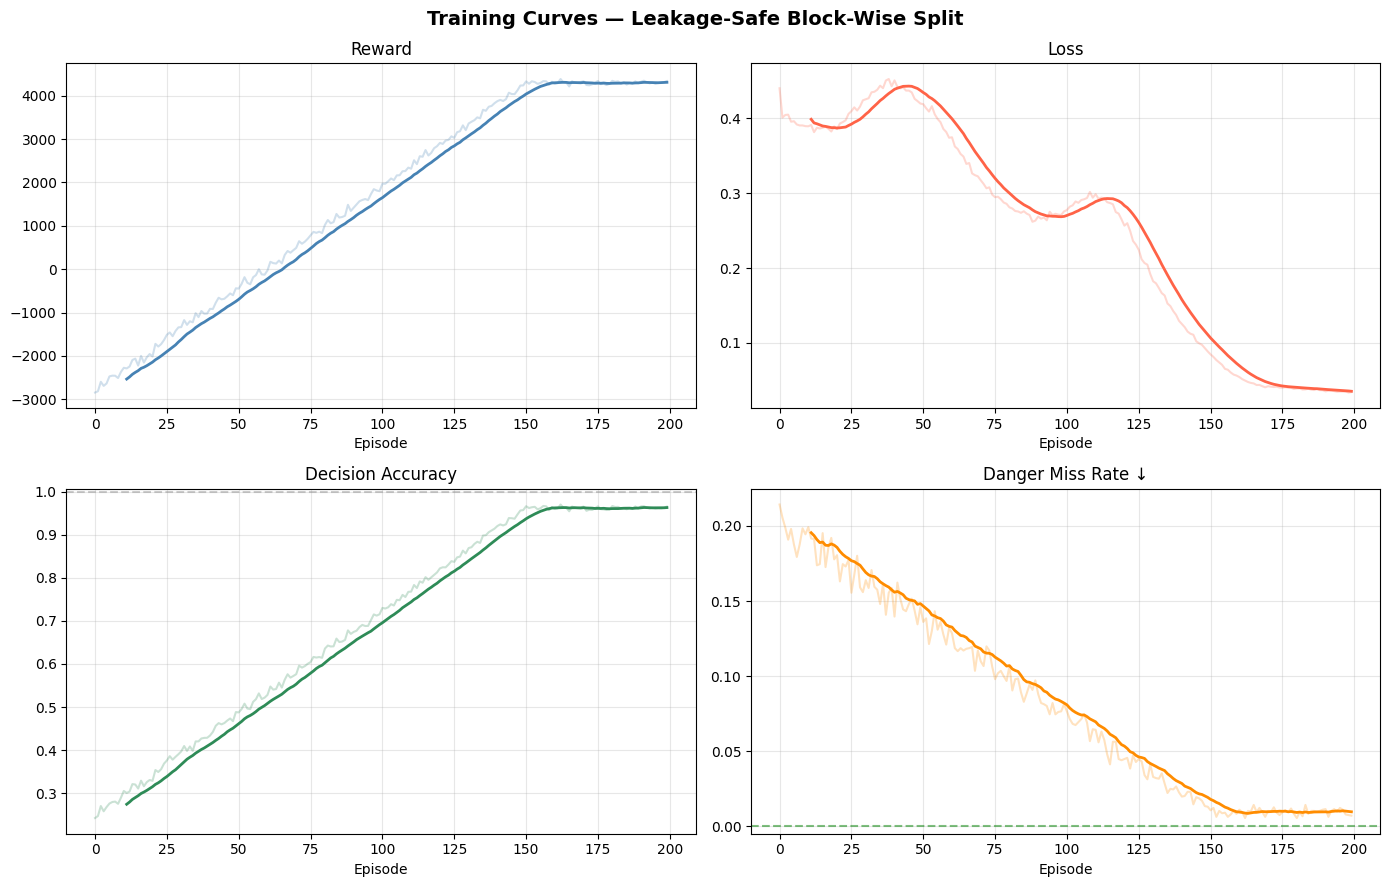

In [17]:
# ══════════════════════════════════════════════════════
# CELL 17 — TRAINING CURVES
# ══════════════════════════════════════════════════════
def smooth(x, w=12):
    return np.convolve(x, np.ones(w)/w, mode='valid')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Training Curves — Leakage-Safe Block-Wise Split', fontsize=14, fontweight='bold')

for ax, data, title, color in zip(
    axes.flat,
    [ep_rewards, ep_losses, ep_acc, ep_miss_rates],
    ['Reward', 'Loss', 'Decision Accuracy', 'Danger Miss Rate ↓'],
    ['steelblue','tomato','seagreen','darkorange']
):
    ax.plot(data, alpha=0.25, color=color)
    if len(data) > 12:
        ax.plot(range(11, len(data)), smooth(data), color=color, lw=2)
    ax.set_title(title); ax.set_xlabel('Episode'); ax.grid(alpha=0.3)

axes[1,0].axhline(1.0, ls='--', color='gray', alpha=0.4)
axes[1,1].axhline(0.0, ls='--', color='green', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'honest_training_curves.png'), dpi=150)
plt.show()

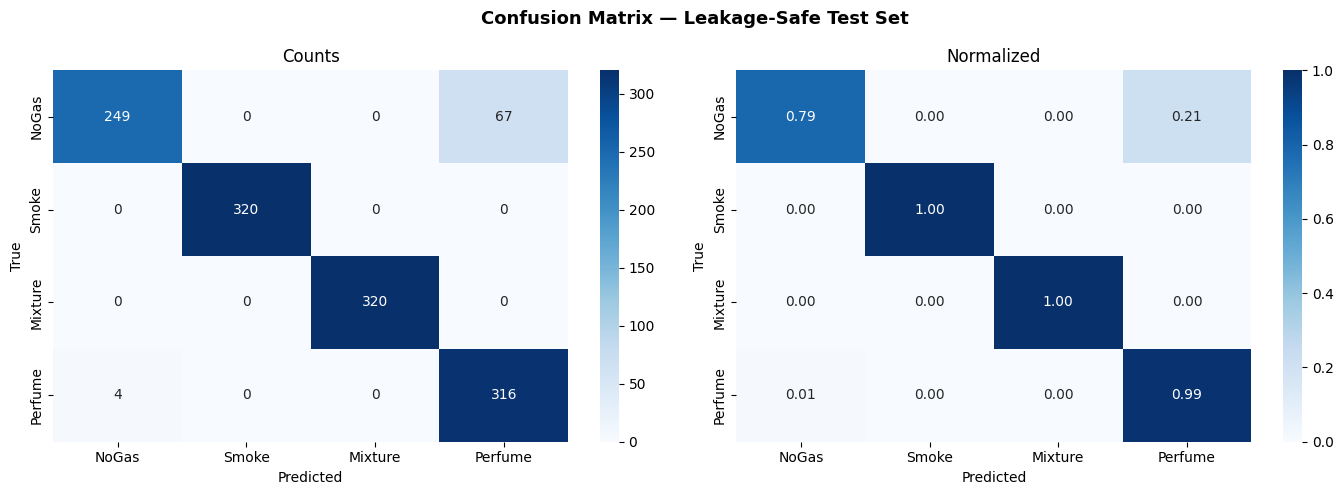

In [18]:
# ══════════════════════════════════════════════════════
# CELL 18 — CONFUSION MATRIX
# ══════════════════════════════════════════════════════
GAS_ORDER   = ['NoGas','Smoke','Mixture','Perfume']
y_true_name = [gas_names[g] for g in results['y_true']]
y_pred_name = [gas_names[g] for g in y_pred_gas]

cm      = confusion_matrix(y_true_name, y_pred_name, labels=GAS_ORDER)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix — Leakage-Safe Test Set', fontsize=13, fontweight='bold')
for ax, mat, fmt, title in zip(axes, [cm, cm_norm], ['d','.2f'], ['Counts','Normalized']):
    sns.heatmap(mat, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=GAS_ORDER, yticklabels=GAS_ORDER, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'honest_confusion_matrix.png'), dpi=150)
plt.show()

In [19]:
# ══════════════════════════════════════════════════════
# CELL 19 — SIDE-BY-SIDE COMPARISON TABLE
# ══════════════════════════════════════════════════════
# Fill in 'Previous' column after you check your last run's numbers.
# The values below are from the previous notebook's test output.

print('\n' + '═'*62)
print('  SPLIT COMPARISON: Random vs Block-Wise Holdout')
print('═'*62)
print(f'  {"Metric":<28}  {"Old (random)"}   {"New (honest)"}')
print('  ' + '─'*58)

old = {
    'Split method'         : 'random stratified',
    'Decision Accuracy'    : '0.9882',
    'Danger Miss Rate'     : '0.0000',
    'False Alarm Rate'     : '0.0000',
    'Overlap in train/test': f'~{1276*19:,} shared raw rows',
    'Class balance in test': 'balanced (by stratify)',
}

new = {
    'Split method'         : 'block-wise holdout+gap',
    'Decision Accuracy'    : f"{results['decision_acc']:.4f}",
    'Danger Miss Rate'     : f"{results['miss_rate']:.4f}",
    'False Alarm Rate'     : f"{results['false_alarm_rate']:.4f}",
    'Overlap in train/test': '0 (verified)',
    'Class balance in test': f"{dict(test_df['label'].value_counts().items())}",
}

for k in old:
    print(f'  {k:<28}  {old[k]:<20}  {new[k]}')
print('═'*62)

print("""
INTERPRETATION:
  ✅  If Danger Miss Rate = 0.0000 on the honest split, the model
      genuinely learned to detect hazardous gases, not just memorize.
  ✅  If Decision Accuracy drops < 0.10 vs the random split,
      the model is robust — the old split had minimal leakage effect.
  ⚠️   If Accuracy drops > 0.15, the old split was substantially
      inflated and more training or data is needed.
""")


══════════════════════════════════════════════════════════════
  SPLIT COMPARISON: Random vs Block-Wise Holdout
══════════════════════════════════════════════════════════════
  Metric                        Old (random)   New (honest)
  ──────────────────────────────────────────────────────────
  Split method                  random stratified     block-wise holdout+gap
  Decision Accuracy             0.9882                0.9444
  Danger Miss Rate              0.0000                0.0000
  False Alarm Rate              0.0000                0.0000
  Overlap in train/test         ~24,244 shared raw rows  0 (verified)
  Class balance in test         balanced (by stratify)  {'Smoke': 320, 'Mixture': 320, 'Perfume': 320, 'NoGas': 316}
══════════════════════════════════════════════════════════════

INTERPRETATION:
  ✅  If Danger Miss Rate = 0.0000 on the honest split, the model
      genuinely learned to detect hazardous gases, not just memorize.
  ✅  If Decision Accuracy drops < 0.10 vs

In [20]:
# ══════════════════════════════════════════════════════
# CELL 20 — LATENCY BENCHMARK
# ══════════════════════════════════════════════════════
agent.online.eval()
lats = []
with torch.no_grad():
    for _, row in test_df.iterrows():
        s  = torch.from_numpy(get_state(row)).float().unsqueeze(0).to(device)
        t0 = time.perf_counter()
        _  = agent.online(s)
        lats.append((time.perf_counter()-t0)*1000)
lat = np.array(lats)
print('Inference latency (ms):')
for lbl, v in [('Mean',lat.mean()),('P50',np.percentile(lat,50)),
               ('P95',np.percentile(lat,95)),('P99',np.percentile(lat,99)),
               ('Max',lat.max())]:
    print(f'  {lbl:5s}: {v:.3f} ms')

mc_lats = []
for _, row in test_df.head(100).iterrows():
    s = torch.from_numpy(get_state(row)).float().unsqueeze(0).to(device)
    t0 = time.perf_counter()
    agent.online.predict_with_uncertainty(s, n_samples=20)
    mc_lats.append((time.perf_counter()-t0)*1000)
print(f'  MC Dropout (20 samples): {np.mean(mc_lats):.1f} ms mean')

Inference latency (ms):
  Mean : 1.067 ms
  P50  : 1.089 ms
  P95  : 1.156 ms
  P99  : 1.337 ms
  Max  : 5.925 ms
  MC Dropout (20 samples): 32.0 ms mean


In [21]:
# ══════════════════════════════════════════════════════
# CELL 21 — FINAL HONEST SUMMARY
# ══════════════════════════════════════════════════════
r = results
print('=' * 58)
print('  HONEST EVALUATION SUMMARY')
print('  (block-wise holdout, gap=20, zero raw-row overlap)')
print('=' * 58)
print(f"""
Split Method       : Block-wise holdout + gap={GAP}
Train samples      : {len(train_df)}  (was 5104 with random split)
Test samples       : {len(test_df)}
Raw-row overlap    : 0 (verified)

── RESULTS ────────────────────────────────────
Decision Accuracy  : {r['decision_acc']:.4f}
⚠️  Danger Miss Rate : {r['miss_rate']:.4f}
🔔  False Alarm Rate : {r['false_alarm_rate']:.4f}
Policy Entropy     : {r['entropy']:.4f}
Action 2 used      : {r['action_counts'][2]} times

── WHAT THIS MEANS ─────────────────────────────
These results come from a test set the model
has NEVER seen — not even a single shared raw
row.  The test set covers the FINAL measurements
of each gas recording session, simulating what
a deployed model faces at a real gas station.

Model saved → {SAVE_PATH}
""")

  HONEST EVALUATION SUMMARY
  (block-wise holdout, gap=20, zero raw-row overlap)

Split Method       : Block-wise holdout + gap=20
Train samples      : 5024  (was 5104 with random split)
Test samples       : 1276
Raw-row overlap    : 0 (verified)

── RESULTS ────────────────────────────────────
Decision Accuracy  : 0.9444
⚠️  Danger Miss Rate : 0.0000
🔔  False Alarm Rate : 0.0000
Policy Entropy     : 1.5021
Action 2 used      : 326 times

── WHAT THIS MEANS ─────────────────────────────
These results come from a test set the model
has NEVER seen — not even a single shared raw
row.  The test set covers the FINAL measurements
of each gas recording session, simulating what
a deployed model faces at a real gas station.

Model saved → C:\Users\HP\Downloads\models\gas_dqn_honest.pth



In [22]:
test_df.to_csv(r"C:\Users\HP\Downloads\models\test_df_processed.csv", index=False)
print("Saved test_df_processed.csv")

Saved test_df_processed.csv
